In [64]:
import pandas as pd

sales = pd.read_csv("C:/Users/lenovo/Downloads/datasets/datasets/Sales_2025.csv")
products = pd.read_csv("C:/Users/lenovo/Downloads/datasets/datasets/Products(AutoRecovered).csv")
customers = pd.read_csv("C:/Users/lenovo/Downloads/datasets/datasets/Customers.csv")
stores = pd.read_csv("C:/Users/lenovo/Downloads/datasets/datasets/Stores.csv")

print(products.columns)

Index(['ProductID', 'ProductName', 'Category', 'UnitPrice'], dtype='object')


In [65]:
df = sales.merge(products, on="ProductID") \
          .merge(customers, on="CustomerID") \
          .merge(stores, on="StoreID")

print(df.head())

   SaleID        Date  CustomerID  ProductID  StoreID  Quantity  UnitPrice_x  \
0       1  2025-04-12           7          2        4         1        630.0   
1       2  2025-12-14           2          5        3         2        157.5   
2       3  2025-09-27           1          8        5         3        525.0   
3       4  2025-04-16           4          8        2         2        525.0   
4       5  2025-03-12           8          3        2         2        315.0   

   TotalSales ProductName     Category  UnitPrice_y CustomerName Region_x  \
0       630.0  Smartphone  Electronics          600        Grace     East   
1       315.0  Smartwatch  Accessories          150          Bob    South   
2      1575.0      Camera  Electronics          500        Alice    North   
3      1050.0      Camera  Electronics          500        David     West   
4       630.0      Tablet  Electronics          300       Hannah     West   

       Segment StoreName       City Region_y  
0     Con

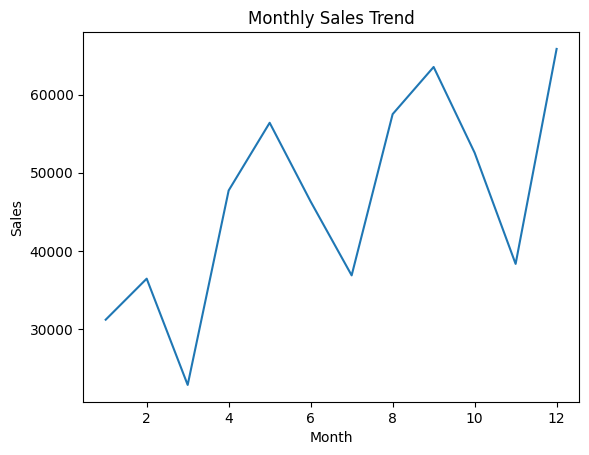

In [66]:
import matplotlib.pyplot as plt

df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month

monthly_sales = df.groupby('Month')['TotalSales'].sum()

plt.plot(monthly_sales.index, monthly_sales.values)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

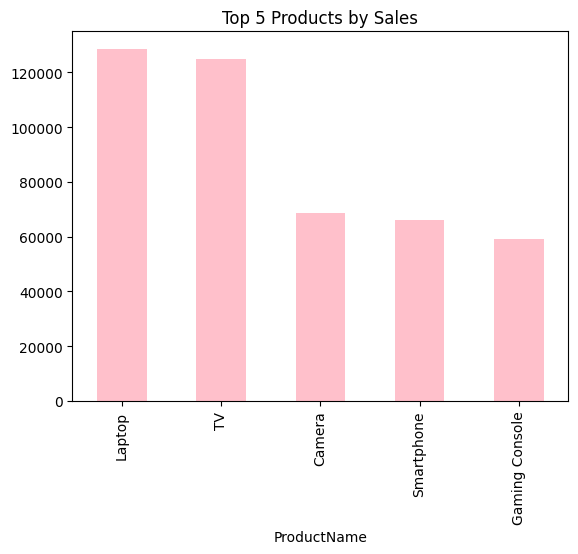

In [101]:
top_products = df.groupby('ProductName')['TotalSales'].sum().sort_values(ascending=False)

top_products.head(5).plot(kind='bar', color='pink')
plt.title("Top 5 Products by Sales")
plt.show()

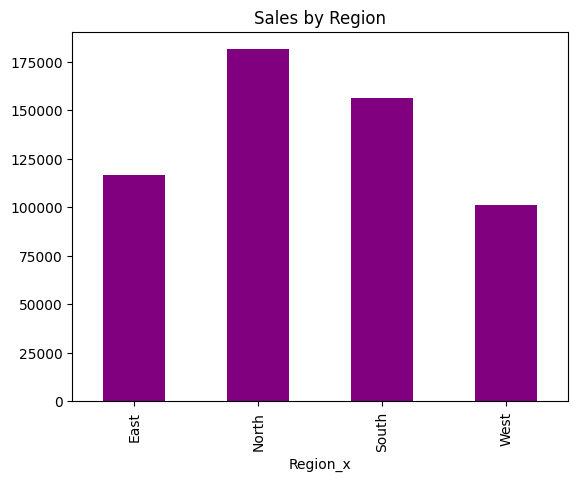

In [96]:
region_sales = df.groupby('Region_x')['TotalSales'].sum()

region_sales.plot(kind='bar', color='purple')
plt.title("Sales by Region")
plt.show()

CustomerName
Alice      61
Eva        58
Charlie    56
Jane       53
Ian        50
Frank      49
Hannah     46
Bob        45
David      41
Grace      41
dtype: int64


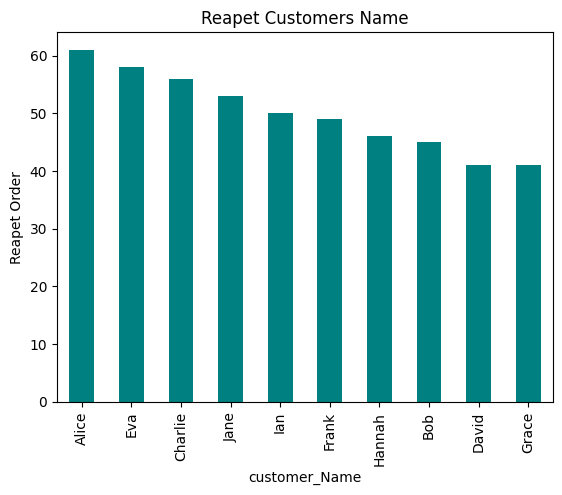

In [126]:
repeat_customers = df.groupby('CustomerName').size()

repeat_customers = repeat_customers[repeat_customers > 1].sort_values(ascending=False)

print(repeat_customers)
repeat_customers.plot(kind='bar', color='teal')
plt.title("Reapet Customers Name")
plt.xlabel("customer_Name")
plt.ylabel("Reapet Order")
plt.show()

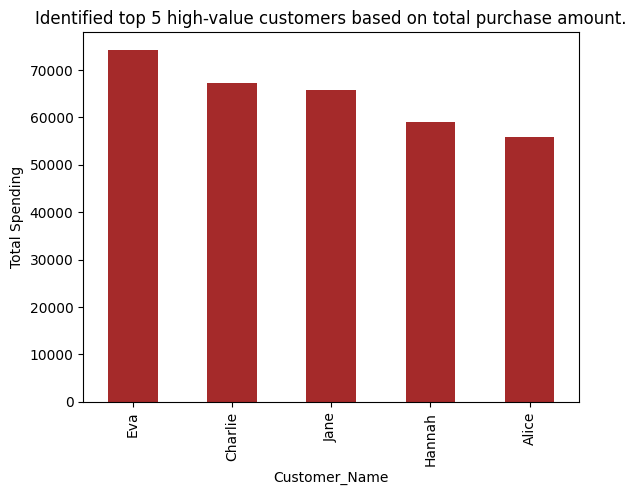

In [99]:
customer_Name = df.groupby('CustomerName')['TotalSales'].sum().sort_values(ascending=False)
customer_Name.head(5).plot(kind='bar', color='brown')
plt.title("Identified top 5 high-value customers based on total purchase amount.")
plt.xlabel("Customer_Name")
plt.ylabel("Total Spending")
plt.show()

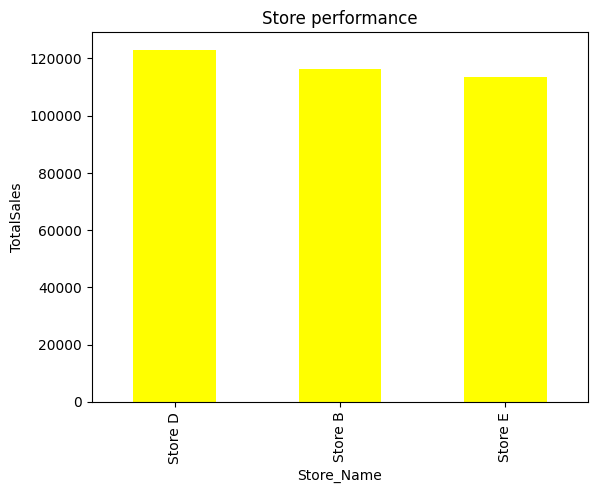

In [93]:
store_Name = df.groupby('StoreName')['TotalSales'].sum().sort_values(ascending=False)
store_Name.head(3).plot(kind='bar', color='yellow')
plt.title("Store performance")
plt.xlabel("Store_Name")
plt.ylabel("TotalSales")
plt.show()

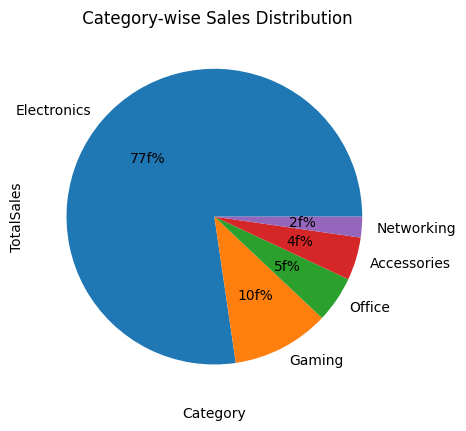

In [72]:
Category =  df.groupby('Category')['TotalSales'].sum().sort_values(ascending=False)
Category.plot(kind='pie', autopct='%1.if%%')
plt.title(" Category-wise Sales Distribution")
plt.xlabel("Category")
#plt.ylabel("TotalSales")
plt.show()

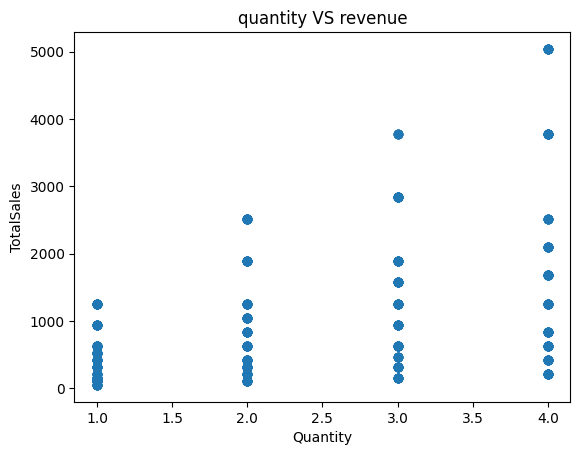

In [73]:
#productName = df.groupby('ProductName')[['TotalSales','Quantity']].sum().sort_values(by='Quantity', ascending = False)
plt.scatter(df['Quantity'], df['TotalSales'])
plt.title("quantity VS revenue")
plt.xlabel("Quantity")
plt.ylabel("TotalSales")

plt.show()


                Quantity  TotalSales
ProductName                         
Camera               131     68775.0
Gaming Console       141     59220.0
Headphones           112      5880.0
Laptop               136    128520.0
Printer              134     28140.0


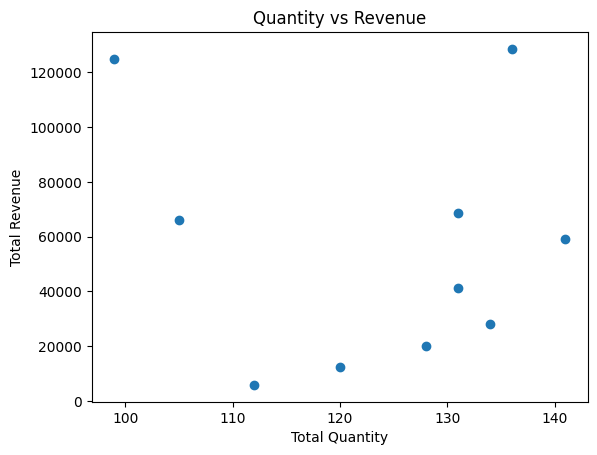

In [74]:
import pandas as pd
import matplotlib.pyplot as plt

# Group by ProductName
product_data = df.groupby('ProductName')[['Quantity', 'TotalSales']].sum()

# Check data
print(product_data.head())

# Scatter Plot
plt.scatter(product_data['Quantity'], product_data['TotalSales'])

# Labels & Title
plt.title("Quantity vs Revenue")
plt.xlabel("Total Quantity")
plt.ylabel("Total Revenue")

plt.show()

       Quantity  TotalSales
month                      
1            79     31185.0
2           118     36435.0
3            53     22837.5
4           111     47722.5
5           133     56385.0


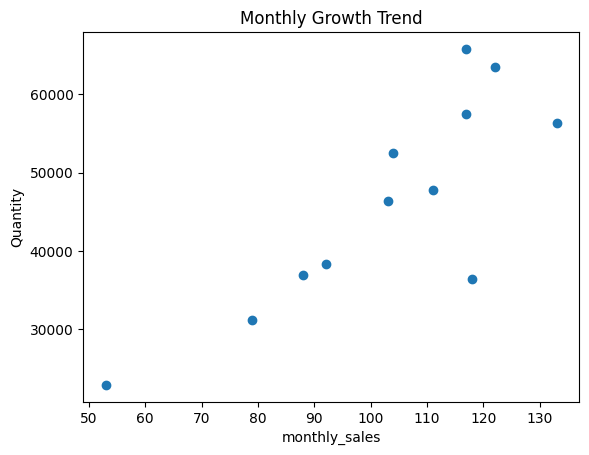

In [75]:
df['month'] = df['Date'].dt.month 
monthly_sales = df.groupby('month')[['Quantity','TotalSales']].sum()
print(monthly_sales.head())
plt.scatter(monthly_sales['Quantity'], monthly_sales['TotalSales'])

plt.title("Monthly Growth Trend")
plt.xlabel("monthly_sales")
plt.ylabel("Quantity")

plt.show()

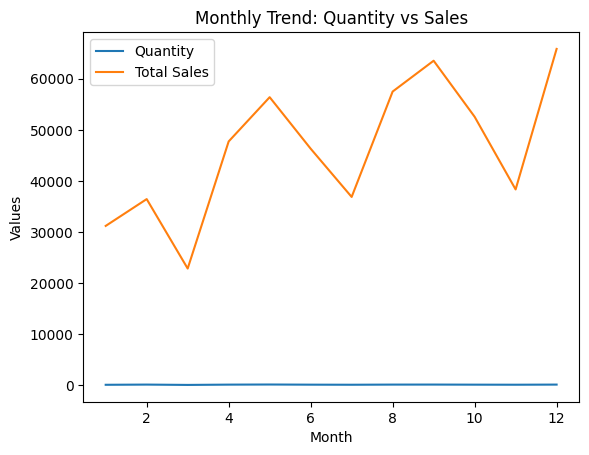

In [76]:
import matplotlib.pyplot as plt

# Month extract
df['Month'] = df['Date'].dt.month

# Grouping
monthly_sales = df.groupby('Month')[['Quantity','TotalSales']].sum()

# Plot 2 lines
plt.plot(monthly_sales.index, monthly_sales['Quantity'], label='Quantity')
plt.plot(monthly_sales.index, monthly_sales['TotalSales'], label='Total Sales')

# Labels + Title
plt.title("Monthly Trend: Quantity vs Sales")
plt.xlabel("Month")
plt.ylabel("Values")

# Legend (important)
plt.legend()

plt.show()

   Region_y ProductName  TotalSales
8   Central          TV     25200.0
18     East          TV     30240.0
23    North      Laptop     23625.0
33     West      Laptop     53865.0


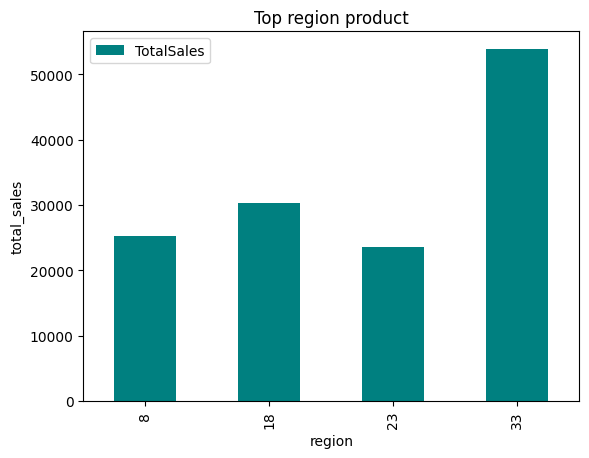

In [121]:
top_region_product = df.groupby(['Region_y','ProductName'])['TotalSales'].sum()
top_region_product = top_region_product.reset_index()
top_region_product = top_region_product.sort_values(['Region_y','TotalSales'], ascending=[True, False])

top_region_product = top_region_product.groupby('Region_y').head(1)

print(top_region_product)

top_region_product.plot(kind='bar', color='teal')
plt.title("Top region product")
plt.xlabel("region")
plt.ylabel("total_sales")
plt.show()


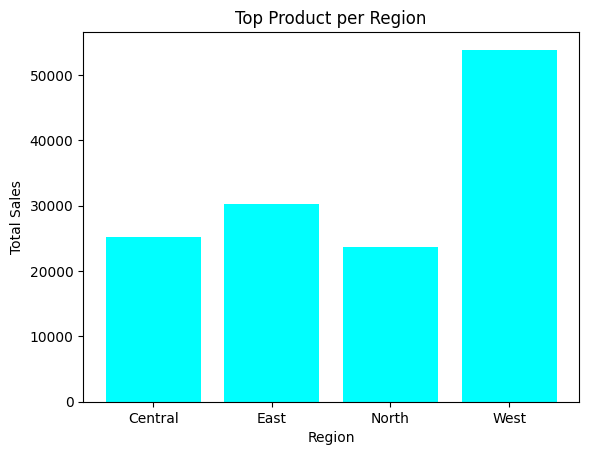

In [98]:
plt.bar(top_region_product['Region_y'], top_region_product['TotalSales'], color = 'cyan')

plt.title("Top Product per Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.show()

   Region_y     ProductName  TotalSales
8   Central              TV     25200.0
3   Central          Laptop     21735.0
6   Central      Smartphone     18270.0
18     East              TV     30240.0
13     East          Laptop     29295.0
10     East          Camera     17850.0
23    North          Laptop     23625.0
26    North      Smartphone     17640.0
28    North              TV     16380.0
33     West          Laptop     53865.0
38     West              TV     52920.0
31     West  Gaming Console     26880.0


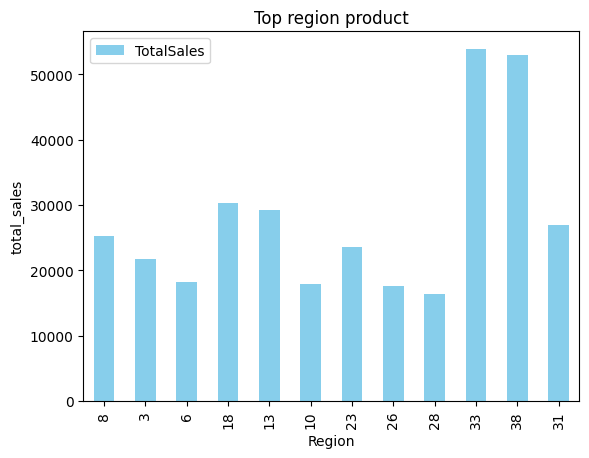

In [122]:
top_region_product = df.groupby(['Region_y','ProductName'])['TotalSales'].sum()
top_region_product = top_region_product.reset_index()
top_region_product = top_region_product.sort_values(['Region_y','TotalSales'], ascending=[True, False])

top_region_product = top_region_product.groupby('Region_y').head(3)

print(top_region_product)

top_region_product.plot(kind='bar', color='skyblue')
plt.title("Top region product")
plt.xlabel("Region")
plt.ylabel("total_sales")
plt.show()

🔥 ✅ 1. Category-wise total sales + percentage

Category
Accessories     4.688091
Electronics    77.315690
Gaming         10.661626
Networking      2.268431
Office          5.066163
Name: TotalSales, dtype: float64


C:\Users\lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


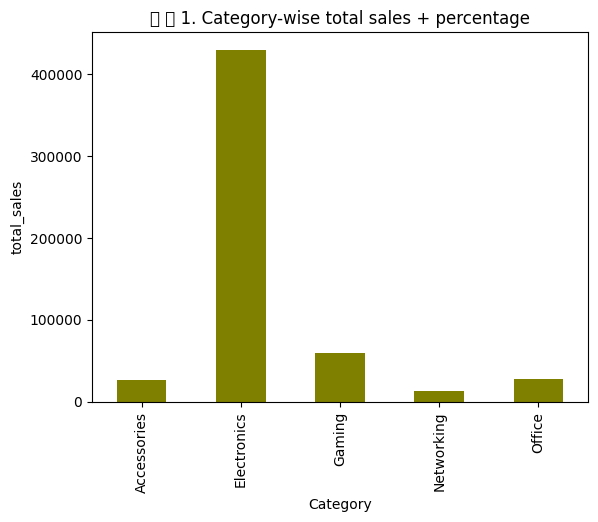

In [124]:
category_sales = df.groupby('Category')['TotalSales'].sum()

percentage = (category_sales / category_sales.sum()) * 100

print(percentage)

category_sales.plot(kind='bar', color='olive')
plt.title("🔥 ✅ 1. Category-wise total sales + percentage")
plt.xlabel("Category")
plt.ylabel("total_sales")
plt.show()

🔥 ✅ 2. Check: Electronics dominate karta hai ya nahi


In [81]:
electronics_share = percentage['Electronics']

if electronics_share > 50:
    print("Electronics dominate karta hai")
else:
    print("Electronics dominate nahi karta")

Electronics dominate karta hai


🔥 ✅ 3. Region-wise category breakdown

  Region_x     Category  TotalSales
0     East  Accessories      4882.5
1     East  Electronics     89775.0
2     East       Gaming     15120.0
3     East   Networking      2520.0
4     East       Office      4200.0


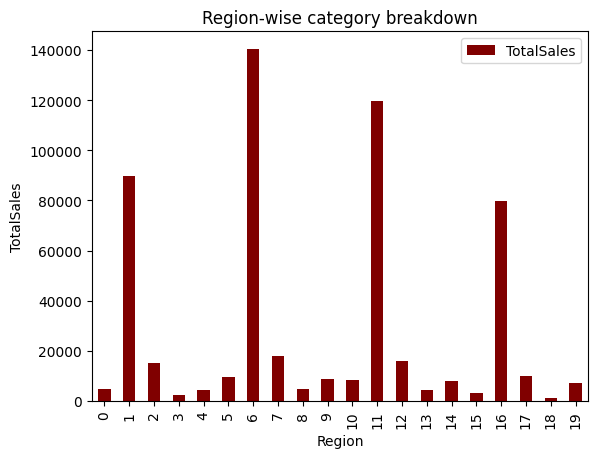

In [120]:
region_category = df.groupby(['Region_x','Category'])['TotalSales'].sum()

region_category = region_category.reset_index()

print(region_category.head())

region_category.plot(kind='bar', color='maroon')
plt.title("Region-wise category breakdown")
plt.xlabel("Region")
plt.ylabel("TotalSales")
plt.show()


  Region_y     Category  TotalSales
0  Central  Accessories      5565.0
1  Central  Electronics     89775.0
2  Central       Gaming     10500.0
3  Central   Networking      3255.0
4  Central       Office      4410.0


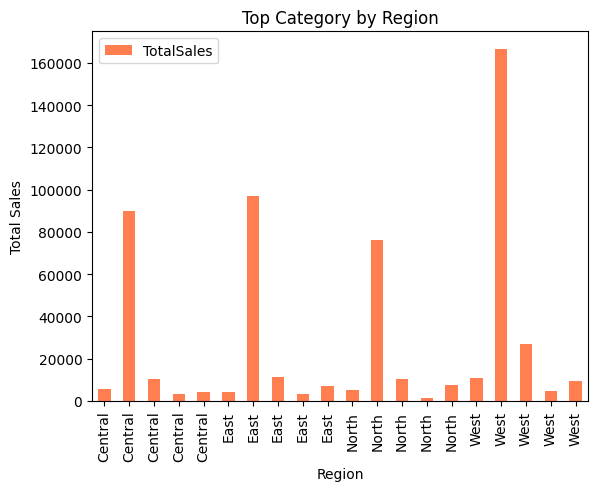

In [125]:
region_category = df.groupby(['Region_y','Category'])['TotalSales'].sum()

region_category = region_category.reset_index()

print(region_category.head())

region_category.plot(kind='bar', x='Region_y', y='TotalSales', color='coral')

plt.title("Top Category by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.show()



🔥 ✅ 4. Har region me top category

   Region_y     Category  TotalSales
1   Central  Electronics     89775.0
6      East  Electronics     96915.0
11    North  Electronics     76125.0
16     West  Electronics    166635.0


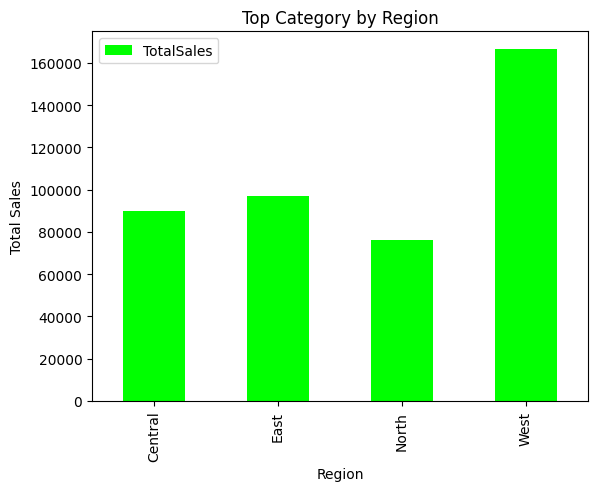

In [ ]:
top_category_region = region_category.sort_values(['Region_y','TotalSales'], ascending=[True, False])

top_category_region = top_category_region.groupby('Region_y').head(1)

print(top_category_region)
#top_category_region = top_category_region.head().plot(kind='pie') #, color = 'orange')

top_category_region.plot(kind='bar', x='Region_y', y='TotalSales', color='lime')

plt.title("Top Category by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.show()

🔥 ✅ 5. Electronics ke andar top products

ProductName
Laptop        128520.0
TV            124740.0
Camera         68775.0
Smartphone     66150.0
Tablet         41265.0
Name: TotalSales, dtype: float64


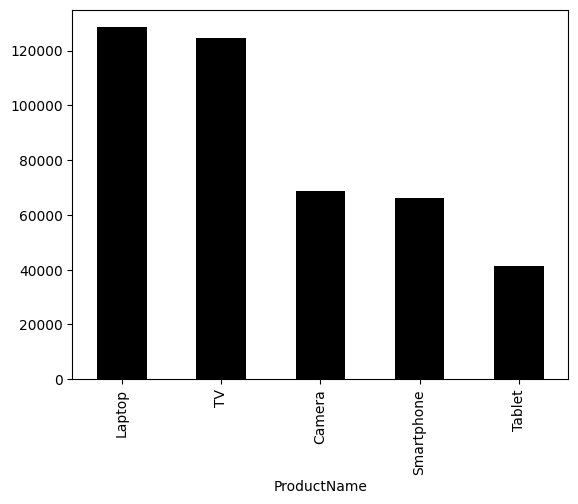

In [106]:
electronics_products = df[df['Category'] == 'Electronics']

top_products = electronics_products.groupby('ProductName')['TotalSales'].sum().sort_values(ascending=False)

print(top_products.head())
top_products = top_products.head().plot(kind='bar', color='black')


TOP 5 STORES 

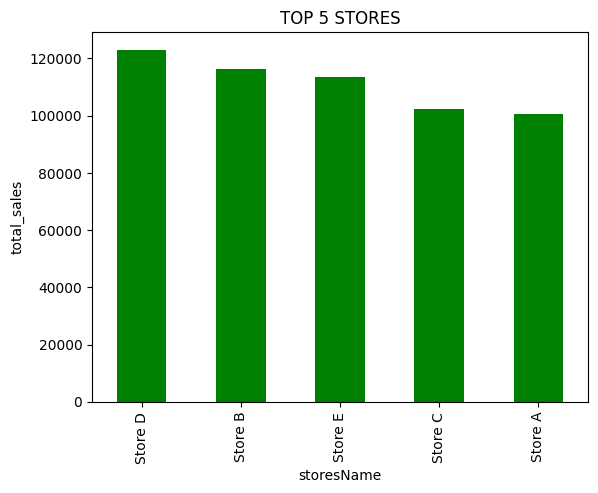

In [90]:
top_5_stores = df.groupby('StoreName')['TotalSales'].sum()
top_5_stores = top_5_stores.sort_values(ascending=False)
top_5 = top_5_stores.head(5)
top_5.plot(kind='bar', color='green')
plt.title("TOP 5 STORES")
plt.xlabel("storesName")
plt.ylabel("total_sales")
plt.show()

